<a href="https://colab.research.google.com/github/maikej910-del/notebooks-Grupo_45/blob/main/Tech_Fase_4_Grupo_45_VFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tech Challenge - Fase 4: Modelo Preditivo para Diagnóstico de Obesidade

**Contexto de Negócio:** Desenvolvimento de um pipeline de Machine Learning de ponta a ponta para classificar e prever o risco de obesidade de pacientes. O objetivo é fornecer uma ferramenta de suporte à decisão clínica e analítica para a equipe médica e diretoria do hospital.

## 1. Configuração do Ambiente e Ingestão de Dados
Estabelecimento das dependências estruturais e ingestão da base de dados bruta diretamente do repositório remoto. Essa abordagem *code-first* elimina a necessidade de uploads manuais, garantindo a reprodutibilidade do experimento em qualquer ambiente.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, RobustScaler

# Configuração de estilo padronizado para as visualizações
sns.set_theme(style="whitegrid", palette="muted")

# URL Raw do arquivo no GitHub do Grupo 45
url_github = 'https://raw.githubusercontent.com/maikej910-del/notebooks-Grupo_45/main/Obesity.csv'

# Padronização das Features (Tradução para o contexto de negócio local)
traducao_colunas = {
    'Gender': ('Genero', {'Female': 'Feminino' , 'Male': 'Masculino'}),
    'Age': ('Idade', 0),
    'Height': ('Altura', 0),
    'Weight': ('Peso', 0),
    'family_history': ('Historico_Familiar', {'yes': 'Sim', 'no': 'Nao'}),
    'FAVC': ('Consumo_Alta_Caloria', {'yes': 'Sim', 'no': 'Nao'}),
    'FCVC': ('Consumo_Vegetais', 0),
    'NCP': ('Refeicoes_Dia', 0),
    'CAEC': ('Consumo_Entre_Refeicoes', {'no': 'Nao', 'Sometimes': 'As vezes', 'Frequently': 'Frequentemente', 'Always': 'Sempre'}),
    'SMOKE': ('Fumante', {'yes': 'Sim', 'no': 'Nao'}),
    'CH2O': ('Consumo_Agua', 0),
    'SCC': ('Monitora_Calorias', {'yes': 'Sim', 'no': 'Nao'}),
    'FAF': ('Frequencia_Ativ_Fisica', 0),
    'TUE': ('Tempo_Exercicio', 0),
    'CALC': ('Consumo_Alcool', {'no': 'Nao', 'Sometimes': 'As vezes', 'Frequently': 'Frequentemente', 'Always': 'Sempre'}),
    'MTRANS': ('Meio_Transporte', {'Automobile': 'Carro', 'Motorbike': 'Moto', 'Public_Transportation': 'Transporte Publico', 'Bike': 'Bicicleta', 'Walking': 'A pe'}),
    'Obesity': ('Classe_Peso', {'Insufficient_Weight': 'Abaixo do peso', 'Normal_Weight': 'Peso normal', 'Overweight_Level_I': 'Sobrepeso I', 'Overweight_Level_II': 'Sobrepeso II', 'Obesity_Type_I': 'Obesidade I', 'Obesity_Type_II': 'Obesidade II', 'Obesity_Type_III': 'Obesidade III'})
}

## 2. Tratamento e Feature Engineering
Criação de funções modulares para mapear os dados em texto e gerar métricas de saúde calculadas (IMC e Score de Atividade). Separamos estrategicamente duas visões da base: `df_modelo` (focada em performance de treino com variáveis numéricas) e `df_analise` (focada em visualização para dashboards).

In [ ]:
def traducao_dataframe(dataframe, tipo):
    df = dataframe
    for coluna_original, traducao in traducao_colunas.items():
        novo_nome    = traducao[0]
        mapa_valores = traducao[1]
        if coluna_original in df.columns:
            if isinstance(mapa_valores, dict):
                df[coluna_original] = df[coluna_original].map(lambda x: mapa_valores[x] if x in mapa_valores else x)
            df.rename(columns={coluna_original: novo_nome}, inplace=True)
    return df

def carregar_obesidade(arquivo, tipo):
    df = pd.read_csv(arquivo, sep=",")
    traducao_dataframe(df, tipo)

    # Conversão de Tipagem (Ajuste de separador decimal)
    if df["Altura"].dtype == 'O':
        df["Altura"] = df["Altura"].astype(str).str.replace(",", ".").astype(float)
    if df["Peso"].dtype == 'O':
        df["Peso"] = df["Peso"].astype(str).str.replace(",", ".").astype(float)

    # Feature Engineering (Cálculo do IMC e Score de Atividade)
    df["IMC"] = round(df["Peso"] / (df["Altura"] ** 2), 2)
    df['Score_Atividade'] = df['Frequencia_Ativ_Fisica'] * df['Tempo_Exercicio']

    # Tratamentos textuais apenas para os Dashboards de Análise
    if tipo == 'analise':
        colunas_escala = ['Consumo_Vegetais', 'Refeicoes_Dia', 'Consumo_Agua', 'Frequencia_Ativ_Fisica', 'Tempo_Exercicio']
        for col in colunas_escala:
            df[col] = df[col].round().astype(int)

        df['Consumo_Vegetais'] = df['Consumo_Vegetais'].map({1: 'Raramente', 2: 'As vezes', 3: 'Sempre'})
        df['Refeicoes_Dia'] = df['Refeicoes_Dia'].map({1: '1 refeicao', 2: '2 refeicoes', 3: '3 refeicoes', 4: '4 ou mais'})
        df['Consumo_Agua'] = df['Consumo_Agua'].map({1: '< 1 L/dia', 2: '1-2 L/dia', 3: '> 2 L/dia'})
        df['Frequencia_Ativ_Fisica'] = df['Frequencia_Ativ_Fisica'].map({0: 'Nenhuma', 1: '1-2 dias/sem', 2: '3-4 dias/sem', 3: '5+ dias/sem'})
        df['Tempo_Exercicio'] = df['Tempo_Exercicio'].map({0: '0-2 h/dia', 1: '3-5 h/dia', 2: '> 5 h/dia'})

        # Faixa etária
        df['Faixa_Etaria'] = pd.cut(df['Idade'], bins=[0, 12, 17, 39, 59, float('inf')], labels=['Infantil','Adolescente', 'Jovem Adulto', 'Adulto Meia Idade', 'Idoso'])

    print(f'Shape do Arquivo {tipo}: {df.shape}')
    return df

# Instanciando as tabelas
df_modelo = carregar_obesidade(url_github, 'modelo')
df_analise = carregar_obesidade(url_github, 'analise')

# Exibindo as 5 primeiras linhas da base de modelagem para validação estrutural
display(df_modelo.head())

Shape do Arquivo modelo: (2111, 19)
Shape do Arquivo analise: (2111, 20)


,Genero,Idade,Altura,Peso,Historico_Familiar,Consumo_Alta_Caloria,Consumo_Vegetais,Refeicoes_Dia,Consumo_Entre_Refeicoes,Fumante,Consumo_Agua,Monitora_Calorias,Frequencia_Ativ_Fisica,Tempo_Exercicio,Consumo_Alcool,Meio_Transporte,Classe_Peso,IMC,Score_Atividade
0,Feminino,21.0,1.62,64.0,Sim,Nao,2.0,3.0,As vezes,Nao,2.0,Nao,0.0,1.0,Nao,Transporte Publico,Peso normal,24.39,0.0
1,Feminino,21.0,1.52,56.0,Sim,Nao,3.0,3.0,As vezes,Sim,3.0,Sim,3.0,0.0,As vezes,Transporte Publico,Peso normal,24.24,0.0
2,Masculino,23.0,1.80,77.0,Sim,Nao,2.0,3.0,As vezes,Nao,2.0,Nao,2.0,1.0,Frequentemente,Transporte Publico,Peso normal,23.77,2.0
3,Masculino,27.0,1.80,87.0,Nao,Nao,3.0,3.0,As vezes,Nao,2.0,Nao,2.0,0.0,Frequentemente,A pe,Sobrepeso I,26.85,0.0
4,Masculino,22.0,1.78,89.8,Nao,Nao,2.0,1.0,As vezes,Nao,2.0,Nao,0.0,0.0,As vezes,Transporte Publico,Sobrepeso II,28.34,0.0


## 3. Análise Exploratória de Dados (EDA)
Validação visual da distribuição dos dados e investigação de correlações lineares e multicolinearidade, assegurando a integridade estatística antes de passarmos as features para o modelo preditivo.

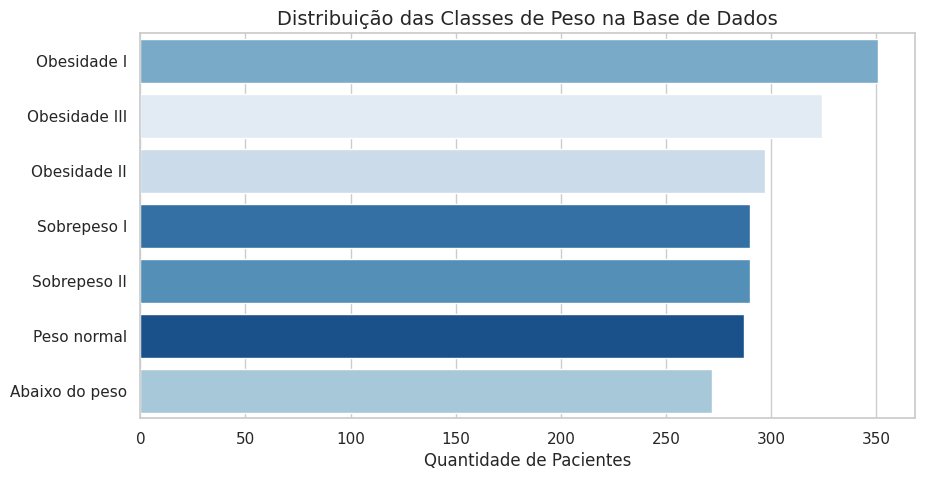

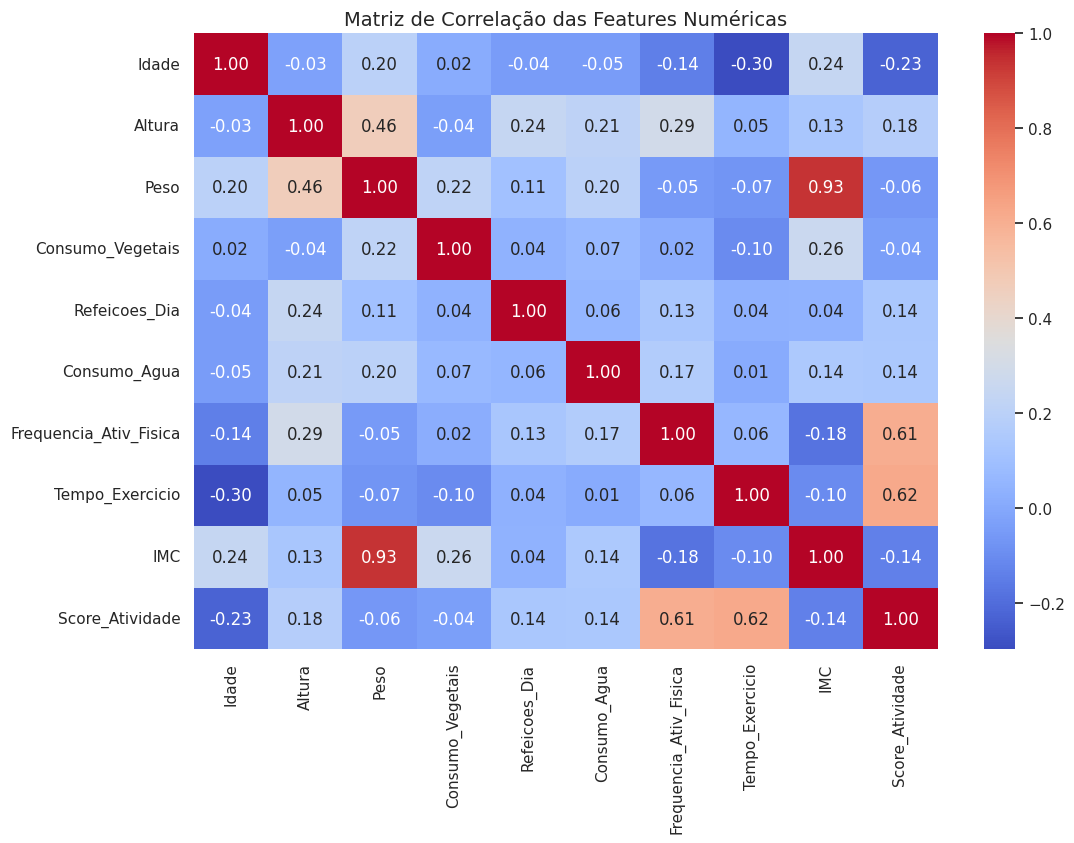

In [ ]:
# Gráfico da distribuição do Target (Corrigido para evitar FutureWarning do Seaborn)
plt.figure(figsize=(10, 5))
sns.countplot(y=df_modelo['Classe_Peso'], order=df_modelo['Classe_Peso'].value_counts().index, hue=df_modelo['Classe_Peso'], palette='Blues_r', legend=False)
plt.title("Distribuição das Classes de Peso na Base de Dados", fontsize=14)
plt.xlabel("Quantidade de Pacientes")
plt.ylabel("")
plt.show()

# Gráfico de Correlação
plt.figure(figsize=(12, 8))
colunas_num = df_modelo.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df_modelo[colunas_num].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação das Features Numéricas", fontsize=14)
plt.show()

## 4. Preparação dos Dados (Feature Selection)
Para impedir que o modelo crie regras baseadas em "Peso" bruto (o que geraria falsos positivos de obesidade para pacientes altos e saudáveis), aplicamos **Feature Selection**: removemos as variáveis de Peso e Altura do pipeline de treinamento.

Isso obriga o algoritmo a avaliar o quadro clínico cruzando o `IMC` estrutural com os hábitos de rotina do paciente.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

# REMOVENDO PESO E ALTURA PARA ELIMINAR VIÉS DE MULTICOLINEARIDADE
X = df_modelo.drop(columns=['Classe_Peso', 'Peso', 'Altura'])
y = df_modelo['Classe_Peso']

# Divisão Treino e Teste (Stratify mantém a proporção do target)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
y_train_1d = y_train.values.ravel()
y_test_1d = y_test.values.ravel()

# Pipeline de Transformação Automático
colunas_numericas = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
colunas_categoricas = X.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessador = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), colunas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), colunas_categoricas)
    ]
)

## 5. Modelagem Preditiva, Avaliação e Deploy
Configuração do `RandomForestClassifier` com parâmetros restritivos de profundidade (`max_depth` e `min_samples`) para barrar o overfitting. Em seguida, exportamos os artefatos de IA gerando dinamicamente a aplicação web (`app.py`) preparada para as instâncias do Streamlit.

Acurácia do Modelo: 94.64%



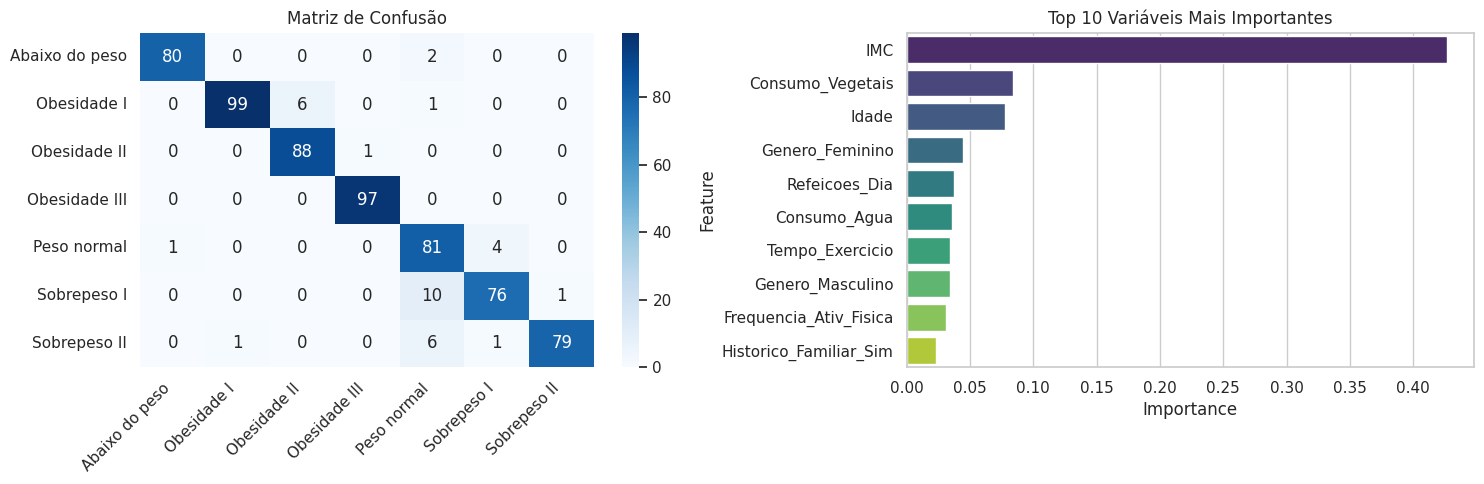

Todos os artefatos foram gerados com sucesso. Iniciando downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib
import pandas as pd
import sklearn
import io
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# 5.1. Construção e ajuste do modelo Random Forest
pipeline_rf = Pipeline([
    ('preprocessor', preprocessador),
    ('classifier', RandomForestClassifier(n_estimators=150, max_depth=12, min_samples_leaf=4, random_state=42, class_weight='balanced', n_jobs=-1))
])

pipeline_rf.fit(X_train, y_train_1d)

# 5.2. Avaliação do modelo no conjunto de teste
y_pred = pipeline_rf.predict(X_test)
acuracia = accuracy_score(y_test_1d, y_pred)
print(f"Acurácia do Modelo: {acuracia * 100:.2f}%\n")

# Geração dos gráficos de validação locais
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Matriz de Confusão
cm = confusion_matrix(y_test_1d, y_pred, labels=pipeline_rf.classes_)
sns.heatmap(cm, annot=True, fmt='d', ax=ax[0], cmap='Blues', xticklabels=pipeline_rf.classes_, yticklabels=pipeline_rf.classes_)
ax[0].set_title("Matriz de Confusão")
ax[0].set_xticklabels(pipeline_rf.classes_, rotation=45, ha='right')

# Importância das Variáveis
importances = pipeline_rf.named_steps['classifier'].feature_importances_
features = pipeline_rf.named_steps['preprocessor'].get_feature_names_out()
features_limpas = [f.replace("num__", "").replace("cat__", "") for f in features]
feat_df = pd.DataFrame({'Feature': features_limpas, 'Importance': importances}).sort_values(by='Importance', ascending=False).head(10)
sns.barplot(x='Importance', y='Feature', data=feat_df, hue='Feature', ax=ax[1], palette='viridis', legend=False)
ax[1].set_title("Top 10 Variáveis Mais Importantes")

plt.tight_layout()
plt.show()

# 5.3. Escrita do código da aplicação Streamlit (app.py)
with open('app.py', 'w', encoding='utf-8') as f:
    f.write("""import streamlit as st
import joblib
import pandas as pd
import io

# Configuração da página do sistema
st.set_page_config(page_title="Diagnóstico de Peso Corporal", layout="wide")
st.title("🔬 Sistema Clínico para Diagnóstico de Peso Corporal")

# Carregamento do modelo treinado
model = joblib.load('modelo_obesidade_rf.pkl')

# Identificação do paciente
nome_paciente = st.text_input("Nome Completo do Paciente", placeholder="Digite aqui...")

# Organização dos campos de entrada em colunas
col1, col2, col3 = st.columns(3)

with col1:
    genero = st.selectbox("Gênero", ["", "Masculino", "Feminino"], index=0)
    idade = st.number_input("Idade", min_value=0, max_value=120, value=None, placeholder="Ex: 25")
    altura = st.number_input("Altura (m)", min_value=0.0, max_value=2.5, value=None, step=0.01, placeholder="Ex: 1.75")
    peso = st.number_input("Peso (kg)", min_value=0.0, max_value=300.0, value=None, step=0.1, placeholder="Ex: 70.5")
    familia = st.selectbox("Histórico Familiar de Obesidade?", ["", "Sim", "Nao"], index=0)
    transporte = st.selectbox("Meio de transporte habitual", ["", "Carro", "Moto", "Bicicleta", "Transporte Publico", "A pe"], index=0)

with col2:
    calorico = st.selectbox("Consumo frequente de alimentos calóricos?", ["", "Sim", "Nao"], index=0)
    vegetais = st.selectbox("Frequência de consumo de vegetais", ["", "Raramente", "As vezes", "Sempre"], index=0)
    refeicoes = st.selectbox("Quantidade de refeições por dia", ["", "1 refeicao", "2 refeicoes", "3 refeicoes", "4 ou mais"], index=0)
    lanches = st.selectbox("Consumo de alimentos entre as refeições", ["", "Nao", "As vezes", "Frequentemente", "Sempre"], index=0)
    agua = st.selectbox("Consumo diário de água", ["", "< 1 L/dia", "1-2 L/dia", "> 2 L/dia"], index=0)

with col3:
    fumante = st.selectbox("Possui hábito de fumar?", ["", "Sim", "Nao"], index=0)
    monitora_cal = st.selectbox("Monitora a ingestão de calorias?", ["", "Sim", "Nao"], index=0)
    ativ_fisica = st.selectbox("Frequência de atividade física", ["", "Nenhuma", "1-2 dias/sem", "3-4 dias/sem", "5+ dias/sem"], index=0)
    telas = st.selectbox("Tempo diário em dispositivos com tela", ["", "0-2 h/dia", "3-5 h/dia", "> 5 h/dia"], index=0)
    alcool = st.selectbox("Consumo de bebidas alcoólicas", ["", "Nao", "As vezes", "Frequentemente", "Sempre"], index=0)


st.markdown("---")

# Execução do modelo preditivo
if st.button("Gerar Diagnóstico"):
    if not nome_paciente or not genero or not idade or not altura or not peso or not familia or not transporte:
        st.warning("Aviso: Por favor, preencha todos os campos do formulário antes de prosseguir.")
    else:
        # Cálculo do Índice de Massa Corporal (IMC)
        imc = round(peso / (altura ** 2), 2)

        # Mapeamento das variáveis categóricas para formato numérico do modelo
        veg_map = {"Raramente": 1, "As vezes": 2, "Sempre": 3}
        ref_map = {"1 refeicao": 1, "2 refeicoes": 2, "3 refeicoes": 3, "4 ou mais": 4}
        h2o_map = {"< 1 L/dia": 1, "1-2 L/dia": 2, "> 2 L/dia": 3}
        atv_map = {"Nenhuma": 0, "1-2 dias/sem": 1, "3-4 dias/sem": 2, "5+ dias/sem": 3}
        tel_map = {"0-2 h/dia": 0, "3-5 h/dia": 1, "> 5 h/dia": 2}

        score_atv = float(atv_map.get(ativ_fisica, 0) * tel_map.get(telas, 0))

        # Estruturação dos dados para predição
        dados = pd.DataFrame([{
            'Genero': genero, 'Idade': float(idade), 'Historico_Familiar': familia,
            'Consumo_Alta_Caloria': calorico, 'Consumo_Vegetais': veg_map.get(vegetais, 2),
            'Refeicoes_Dia': ref_map.get(refeicoes, 3), 'Consumo_Entre_Refeicoes': lanches,
            'Fumante': fumante, 'Consumo_Agua': h2o_map.get(agua, 2),
            'Monitora_Calorias': monitora_cal, 'Frequencia_Ativ_Fisica': atv_map.get(ativ_fisica, 0),
            'Tempo_Exercicio': tel_map.get(telas, 0), 'Consumo_Alcool': alcool,
            'Meio_Transporte': transporte, 'IMC': float(imc), 'Score_Atividade': score_atv
        }])

        # Realização da predição
        resultado = model.predict(dados)[0]

        st.markdown("### 📋 Resultado do Diagnóstico")
        st.success(f"**Paciente:** {nome_paciente}  |  **Diagnóstico Clínico:** {resultado}")

        # Geração do arquivo Excel para exportação dos dados
        df_export = dados.copy()
        df_export.insert(0, 'Nome_Paciente', nome_paciente)
        df_export['Resultado_Diagnostico'] = resultado

        output = io.BytesIO()
        with pd.ExcelWriter(output, engine='xlsxwriter') as writer:
            df_export.to_excel(writer, index=False, sheet_name='Diagnostico')

        st.download_button(
            label="📥 Exportar Relatório da Avaliação (Excel)",
            data=output.getvalue(),
            file_name=f"diagnostico_{nome_paciente.lower().replace(' ', '_')}.xlsx",
            mime="application/vnd.openxmlformats-officedocument.spreadsheetml.sheet"
        )
""")

# 5.4. Geração do arquivo de dependências (requirements.txt)
with open('requirements.txt', 'w', encoding='utf-8') as f:
    f.write(f"streamlit\npandas=={pd.__version__}\nscikit-learn=={sklearn.__version__}\njoblib=={joblib.__version__}\nxlsxwriter\n")

# Salvando os arquivos finais gerados para download
joblib.dump(pipeline_rf, 'modelo_obesidade_rf.pkl')
df_analise.to_csv('obesity_tratada_grupo45.csv', index=False, sep=';', decimal=',', encoding='utf-8-sig')

print("Todos os artefatos foram gerados com sucesso. Iniciando downloads...")
files.download('modelo_obesidade_rf.pkl')
files.download('obesity_tratada_grupo45.csv')
files.download('app.py')
files.download('requirements.txt')